In [1]:
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

images_path = Path("../data/images")

image_files = list(images_path.glob("*.jpg"))

print(f"Total Images: {len(image_files)}")

Total Images: 44441


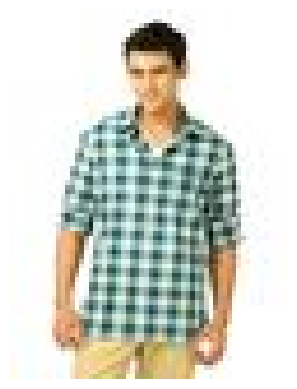

In [2]:
img = Image.open(image_files[0])

plt.imshow(img)
plt.axis("off")
plt.show()

In [3]:
import open_clip

model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="laion2b_s34b_b79k"
)

tokenizer = open_clip.get_tokenizer("ViT-B-32")

In [4]:
from PIL import Image
import torch

image = preprocess(Image.open(image_files[0])).unsqueeze(0)

with torch.no_grad():
    embedding = model.encode_image(image)
    embedding /= embedding.norm(dim=-1, keepdim=True)

print("Embedding shape:", embedding.shape)
print(embedding)

Embedding shape: torch.Size([1, 512])
tensor([[ 1.4936e-02,  2.6582e-02,  5.7570e-03, -9.0531e-02,  2.4100e-02,
         -4.6096e-02,  3.7070e-02, -6.0136e-02, -4.0198e-02, -1.2409e-03,
          1.6545e-02,  1.6376e-02,  7.4050e-03,  3.4073e-02, -2.7558e-02,
         -6.0996e-02, -9.6494e-02,  1.6718e-02, -1.7725e-03, -4.4747e-02,
         -3.3016e-02, -5.7700e-02, -4.2026e-02,  2.3604e-02, -5.8029e-02,
          2.5793e-02,  1.7813e-03, -2.5292e-02,  2.8608e-02, -4.7577e-03,
         -8.2322e-03,  3.9101e-02,  1.4294e-02, -2.0670e-02,  1.7720e-04,
         -4.9295e-02, -5.5330e-02, -4.7043e-02,  3.6915e-02, -6.1403e-03,
         -3.5405e-03,  1.0825e-02, -8.4798e-03, -4.7721e-02,  1.2797e-02,
          9.8885e-03, -1.0364e-01,  1.2951e-02,  1.8038e-02,  5.9491e-02,
          2.4276e-02,  2.0725e-02, -5.4019e-02,  2.2507e-02, -8.4793e-02,
          4.7294e-02, -4.9315e-03, -4.2407e-02,  1.4283e-02, -3.2219e-02,
         -6.3498e-02, -6.0412e-03, -2.9885e-03,  4.3759e-02,  1.9350e-02,


In [5]:
image1 = preprocess(Image.open(image_files[0])).unsqueeze(0)
image2 = preprocess(Image.open(image_files[1])).unsqueeze(0)

with torch.no_grad():
    emb1 = model.encode_image(image1)
    emb2 = model.encode_image(image2)

    emb1 /= emb1.norm(dim=-1, keepdim=True)
    emb2 /= emb2.norm(dim=-1, keepdim=True)

similarity = (emb1 @ emb2.T).item()

print(f"Similarity Score: {similarity:.4f}")

Similarity Score: 0.3370


In [6]:
from tqdm import tqdm

embeddings = []
image_paths = []

for img_path in tqdm(image_files[:500]):
    image = preprocess(Image.open(img_path).convert("RGB")).unsqueeze(0)

    with torch.no_grad():
        emb = model.encode_image(image)
        emb /= emb.norm(dim=-1, keepdim=True)

    embeddings.append(emb.squeeze(0))
    image_paths.append(img_path)

embeddings = torch.stack(embeddings)

print(embeddings.shape)

100%|██████████| 500/500 [00:18<00:00, 26.87it/s]

torch.Size([500, 512])


In [7]:
query_image = embeddings[0]

similarities = embeddings @ query_image

top5 = torch.topk(similarities, k=5)

print(top5.indices)
print(top5.values)

tensor([  0, 172, 279,  41, 227])
tensor([1.0000, 0.9054, 0.8841, 0.8773, 0.8733])


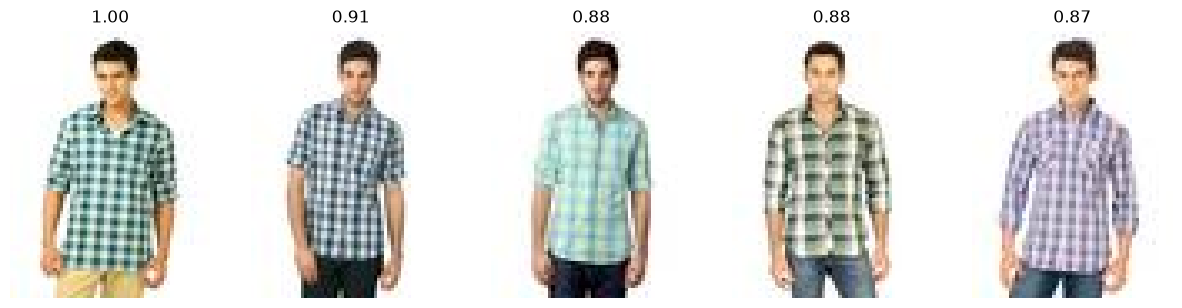

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for ax, idx in zip(axes, top5.indices):
    img = Image.open(image_paths[idx])
    ax.imshow(img)
    ax.set_title(f"{similarities[idx]:.2f}")
    ax.axis("off")

plt.show()

In [9]:
torch.save(
    {
        "embeddings": embeddings,
        "image_paths": [str(path) for path in image_paths]
    },
    "embeddings.pt"
)

print("✅ Embeddings saved successfully!")

✅ Embeddings saved successfully!


In [10]:
saved_data = torch.load("embeddings.pt")

embeddings = saved_data["embeddings"]
image_paths = saved_data["image_paths"]

print("✅ Embeddings loaded!")
print(embeddings.shape)

✅ Embeddings loaded!
torch.Size([500, 512])


In [11]:
def search_similar(query_image_path, top_k=5):
    # Generate query embedding
    query = preprocess(Image.open(query_image_path).convert("RGB")).unsqueeze(0)

    with torch.no_grad():
        query_embedding = model.encode_image(query)
        query_embedding /= query_embedding.norm(dim=-1, keepdim=True)

    # Compute similarities
    similarities = embeddings @ query_embedding.squeeze(0)

    # Get one extra result (because the first one is the query itself)
    topk = torch.topk(similarities, k=top_k + 1)

    # Remove the query image
    indices = topk.indices[1:]
    scores = topk.values[1:]

    return indices, scores

In [12]:
indices, scores = search_similar(image_paths[10], top_k=5)

print(indices)
print(scores)

tensor([262, 496, 438, 155, 167])
tensor([0.7742, 0.7452, 0.6959, 0.6900, 0.6609])


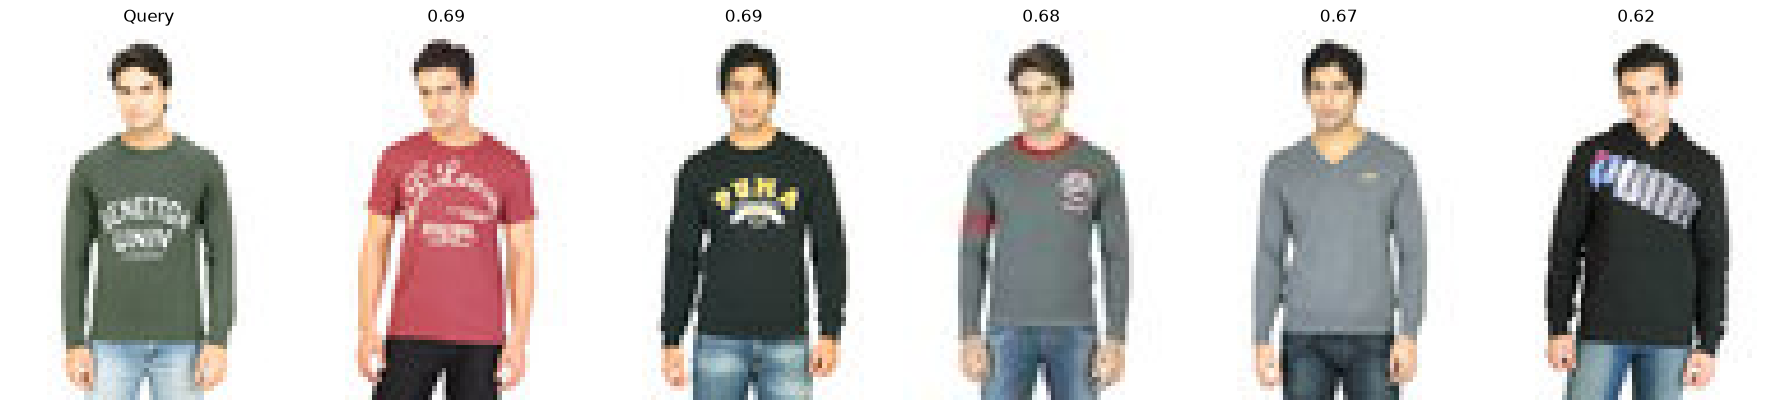

In [13]:
query_path = image_paths[201]

indices, scores = search_similar(query_path)

fig, axes = plt.subplots(1, 6, figsize=(18, 4))

# Query Image
axes[0].imshow(Image.open(query_path))
axes[0].set_title("Query")
axes[0].axis("off")

# Retrieved Images
for i, (idx, score) in enumerate(zip(indices, scores), start=1):
    axes[i].imshow(Image.open(image_paths[idx]))
    axes[i].set_title(f"{score:.2f}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [14]:
import faiss
import numpy as np

In [15]:
embeddings_np = embeddings.cpu().numpy().astype("float32")

print(embeddings_np.shape)

(500, 512)


In [16]:
dimension = embeddings_np.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(embeddings_np)

print("Number of vectors:", index.ntotal)

Number of vectors: 500


In [17]:
def search_similar_faiss(query_image_path, top_k=5):
    # Load and preprocess query image
    query = preprocess(Image.open(query_image_path).convert("RGB")).unsqueeze(0)

    # Generate embedding
    with torch.no_grad():
        query_embedding = model.encode_image(query)
        query_embedding /= query_embedding.norm(dim=-1, keepdim=True)

    # Convert to NumPy float32
    query_embedding = query_embedding.cpu().numpy().astype("float32")

    # Search FAISS
    scores, indices = index.search(query_embedding, top_k + 1)

    return indices[0][1:], scores[0][1:]

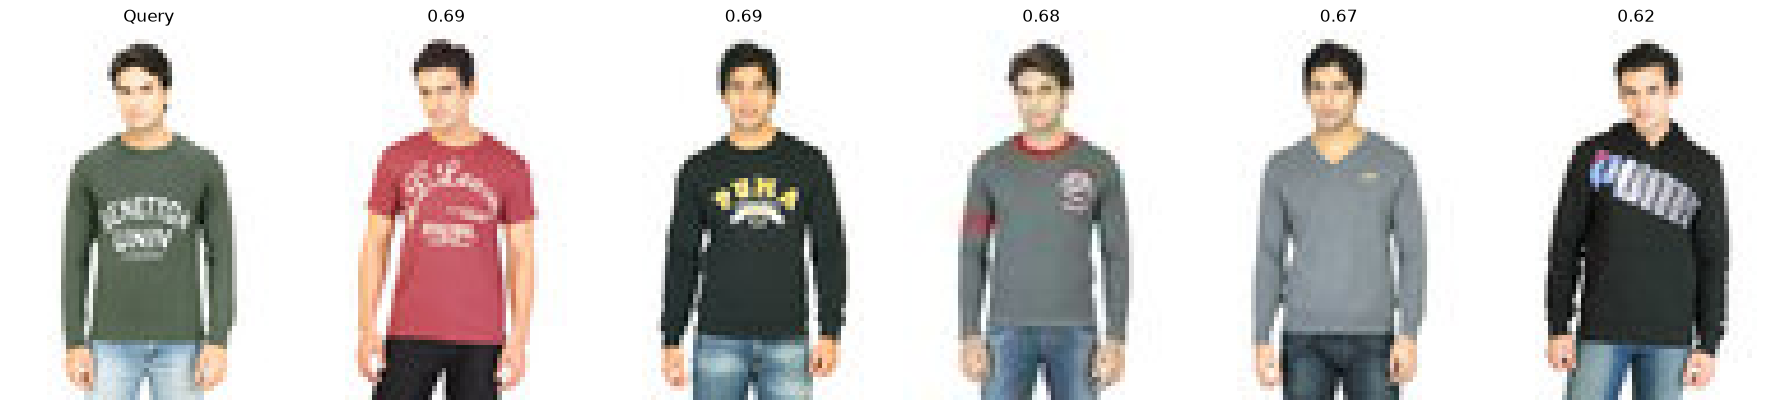

In [18]:
query_path = image_paths[201]

indices, scores = search_similar_faiss(query_path)

fig, axes = plt.subplots(1, 6, figsize=(18, 4))

# Query Image
axes[0].imshow(Image.open(query_path))
axes[0].set_title("Query")
axes[0].axis("off")

# Retrieved Images
for i, (idx, score) in enumerate(zip(indices, scores), start=1):
    axes[i].imshow(Image.open(image_paths[idx]))
    axes[i].set_title(f"{score:.2f}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [19]:
import time

In [ ]:
query_path = image_paths[201]

start = time.perf_counter()

for _ in range(100):
    search_similar(query_path)

end = time.perf_counter()

print(f"Brute Force Average Time: {(end-start)/100:.6f} seconds")

In [21]:
start = time.perf_counter()

for _ in range(100):
    search_similar_faiss(query_path)

end = time.perf_counter()

print(f"FAISS Average Time: {(end-start)/100:.6f} seconds")

FAISS Average Time: 0.044149 seconds


In [22]:
repeat_factor = 100

large_embeddings = np.tile(embeddings_np, (repeat_factor, 1))

print(large_embeddings.shape)

(50000, 512)


In [23]:
large_index = faiss.IndexFlatIP(512)

large_index.add(large_embeddings)

print(large_index.ntotal)

50000


In [24]:
query = preprocess(Image.open(query_path).convert("RGB")).unsqueeze(0)

with torch.no_grad():
    query_embedding = model.encode_image(query)
    query_embedding /= query_embedding.norm(dim=-1, keepdim=True)

query_embedding = query_embedding.squeeze(0).cpu().numpy().astype("float32")

In [ ]:
start = time.perf_counter()

for _ in range(100):
    similarities = large_embeddings @ query_embedding
    np.argpartition(similarities, -5)[-5:]

end = time.perf_counter()

print(f"Large Brute Force: {(end-start)/100:.6f} sec")

Large Brute Force: 0.003912 sec


: 